In [50]:
import torch
import torch.nn as nn
import numpy as np
import random
import urllib.request

# 1. Download the Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

# 2. Read the text file into a string
with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Full dataset length: {len(text)} characters")

# FIX #2: Use a smaller slice during development to avoid 1.1M samples
text = text[:50000]
print(f"Using slice: {len(text)} characters")

# 3. Build vocabulary with a special <sos> token
SOS_TOKEN = "<sos>"

chars = sorted(list(set(text)))
vocab = [SOS_TOKEN] + chars
vocab_size = len(vocab)

char_to_ix = {ch: i for i, ch in enumerate(vocab)}
ix_to_char = {i: ch for i, ch in enumerate(vocab)}

SOS_IDX = char_to_ix[SOS_TOKEN]

print(f"Vocabulary size: {vocab_size} tokens (including <sos>)")

Full dataset length: 1115394 characters
Using slice: 50000 characters
Vocabulary size: 60 tokens (including <sos>)


#### Character Generation using LSTM

In [51]:
def text_to_indices(string):
    """Converts a string to a tensor of integer indices."""
    indices = [char_to_ix[char] for char in string]
    return torch.tensor(indices, dtype=torch.long)

def decoder_target_from_string(string):
    """Builds decoder target: [<sos>, c1, c2, ..., cN]."""
    indices = [SOS_IDX] + [char_to_ix[char] for char in string]
    return torch.tensor(indices, dtype=torch.long)

def indices_to_text(indices):
    chars_out = []
    for idx in indices:
        token = ix_to_char[int(idx)]
        if token != SOS_TOKEN:
            chars_out.append(token)
    return "".join(chars_out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [41]:
class CharEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, hidden_size, batch_first=True)

    def forward(self, x):
        # x: (batch, seq_len) of indices
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        return lstm_out, (hidden, cell)


In [52]:
class CharAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden)
        # encoder_outputs: (batch, src_len, hidden)
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch, src_len, hidden)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)               # (batch, src_len)
        return torch.softmax(attention, dim=1)

In [53]:
class CharDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size, attention):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.attention = attention
        self.lstm = nn.LSTM(embedding_size + hidden_size, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, input_char, hidden, cell, encoder_outputs):
        # input_char: (batch,) indices
        input_char = input_char.unsqueeze(1)                # (batch, 1)
        embedded = self.embedding(input_char)               # (batch, 1, emb)

        attn_weights = self.attention(hidden[-1], encoder_outputs)             # (batch, src_len)
        attn_applied = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)   # (batch, 1, hidden)

        lstm_input = torch.cat((embedded, attn_applied), dim=2)                # (batch, 1, emb+hidden)
        lstm_out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        output = torch.cat((lstm_out.squeeze(1), attn_applied.squeeze(1)), dim=1)  # (batch, 2*hidden)
        prediction = self.fc_out(output)                                           # (batch, vocab_size)

        return prediction, hidden, cell

In [54]:
class CharSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        src: (batch, src_len)
        trg: (batch, trg_len) where trg[:, 0] is always <sos>
             and trg[:, 1:] are the actual character targets
        """
        batch_size = src.size(0)
        trg_len = trg.size(1)
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size, device=self.device)

        encoder_out, (hidden, cell) = self.encoder(src)

        # Start decoding from <sos>
        input_token = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell, encoder_out)
            outputs[:, t, :] = output

            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[:, t] if teacher_force else top1

        return outputs

In [55]:
hidden_size = 256
num_epoch = 20
batch_size = 64
seq_len = 20
lr = 0.001
embedding_size = 256

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# Dataset
# src  = text[i : i+seq_len]
# trg  = [<sos>] + text[i+1 : i+seq_len+1]
samples = []
for i in range(len(text) - seq_len):
    input_seq  = text[i:i+seq_len]
    target_seq = text[i+1:i+seq_len+1]

    input_tensor  = text_to_indices(input_seq)              # (seq_len,)
    target_tensor = decoder_target_from_string(target_seq)  # (seq_len + 1,)

    samples.append((input_tensor, target_tensor))

train_size = int(0.8 * len(samples))
val_size   = len(samples) - train_size

train_dataset, val_dataset = random_split(samples, [train_size, val_size])

def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs  = torch.stack(inputs)   # (batch, seq_len)
    targets = torch.stack(targets)  # (batch, seq_len + 1)
    return inputs, targets

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
valloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print("Sample input shape: ", samples[0][0].shape)
print("Sample target shape:", samples[0][1].shape)
print("Sample target starts with <sos> index:", samples[0][1][0].item())

Sample input shape:  torch.Size([20])
Sample target shape: torch.Size([21])
Sample target starts with <sos> index: 0


In [57]:
enc   = CharEncoder(vocab_size, hidden_size, embedding_size).to(device)
attn  = CharAttention(hidden_size).to(device)
dec   = CharDecoder(vocab_size, hidden_size, embedding_size, attention=attn).to(device)
model = CharSeq2Seq(enc, dec, device).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 1,507,900


Epoch 1/20 - Train Loss: 0.8165, Train Acc: 0.7790, Val Loss: 0.1303, Val Acc: 0.9667
Epoch 2/20 - Train Loss: 0.1246, Train Acc: 0.9669, Val Loss: 0.1091, Val Acc: 0.9702
Epoch 3/20 - Train Loss: 0.1109, Train Acc: 0.9694, Val Loss: 0.0985, Val Acc: 0.9718
Epoch 4/20 - Train Loss: 0.1109, Train Acc: 0.9695, Val Loss: 0.1731, Val Acc: 0.9630
Epoch 5/20 - Train Loss: 0.1006, Train Acc: 0.9715, Val Loss: 0.1052, Val Acc: 0.9716
Epoch 6/20 - Train Loss: 0.0918, Train Acc: 0.9733, Val Loss: 0.1054, Val Acc: 0.9721
Epoch 7/20 - Train Loss: 0.0938, Train Acc: 0.9731, Val Loss: 0.0976, Val Acc: 0.9732
Epoch 8/20 - Train Loss: 0.0893, Train Acc: 0.9741, Val Loss: 0.1031, Val Acc: 0.9719
Epoch 9/20 - Train Loss: 0.0829, Train Acc: 0.9754, Val Loss: 0.0887, Val Acc: 0.9745
Epoch 10/20 - Train Loss: 0.0808, Train Acc: 0.9759, Val Loss: 0.2093, Val Acc: 0.9601
Epoch 11/20 - Train Loss: 0.0873, Train Acc: 0.9746, Val Loss: 0.0903, Val Acc: 0.9741
Epoch 12/20 - Train Loss: 0.0745, Train Acc: 0.9772,

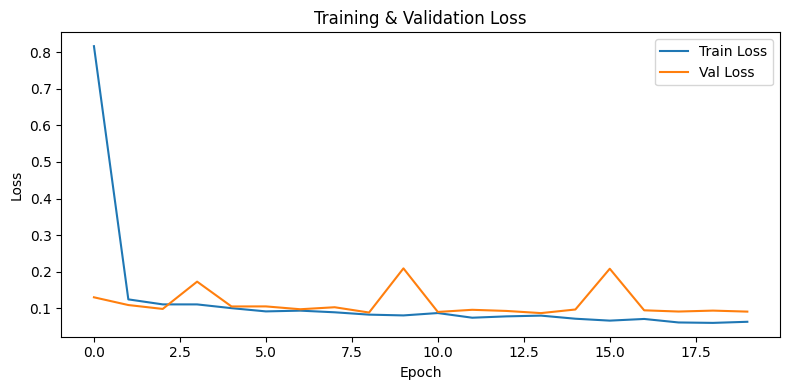

In [58]:
train_losses, val_losses = [], []

for epoch in range(num_epoch):
    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total   = 0

    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs, targets, teacher_forcing_ratio=0.5)

        # Ignore position 0 (the <sos> slot — it is never a prediction target)
        outputs_for_loss = outputs[:, 1:, :].reshape(-1, vocab_size)   # (batch * seq_len, vocab)
        targets_for_loss = targets[:, 1:].reshape(-1)                  # (batch * seq_len)

        loss = criterion(outputs_for_loss, targets_for_loss)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_train_loss += loss.item() * targets_for_loss.size(0)
        predicted     = outputs_for_loss.argmax(dim=1)
        train_total  += targets_for_loss.size(0)
        train_correct += predicted.eq(targets_for_loss).sum().item()

    train_loss = running_train_loss / train_total
    train_acc  = train_correct / train_total
    train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for inputs, targets in valloader:
            inputs, targets = inputs.to(device), targets.to(device)

            # No teacher forcing during validation
            outputs = model(inputs, targets, teacher_forcing_ratio=0.0)

            outputs_for_loss = outputs[:, 1:, :].reshape(-1, vocab_size)
            targets_for_loss = targets[:, 1:].reshape(-1)

            loss = criterion(outputs_for_loss, targets_for_loss)
            running_val_loss += loss.item() * targets_for_loss.size(0)

            predicted   = outputs_for_loss.argmax(dim=1)
            val_total  += targets_for_loss.size(0)
            val_correct += predicted.eq(targets_for_loss).sum().item()

    val_loss = running_val_loss / val_total
    val_acc  = val_correct / val_total
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epoch} - "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

# ── Loss curve ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss"); plt.legend(); plt.tight_layout()
plt.show()

In [60]:
def predict_next_char(model, context):
    """
    Predict the next character after the given context.
    Uses the LAST decoder step output (position seq_len), which
    corresponds to the character immediately after the context window.
    """
    model.eval()

    # Pad or trim context to exactly seq_len characters
    context = context[-seq_len:]
    if len(context) < seq_len:
        context = " " * (seq_len - len(context)) + context

    src = text_to_indices(context).unsqueeze(0).to(device)  # (1, seq_len)

    # FIX #5: Only trg[:, 0] matters (seeds the decoder with <sos>).
    # With teacher_forcing_ratio=0.0 the decoder auto-regressively uses
    # its own previous outputs — the remaining trg positions are never read.
    trg = torch.full((1, seq_len + 1), SOS_IDX, dtype=torch.long, device=device)

    with torch.no_grad():
        outputs = model(src, trg, teacher_forcing_ratio=0.0)  # (1, seq_len+1, vocab)

    # The last decoder step predicts the character just beyond the context
    next_idx = outputs[:, -1, :].argmax(dim=1).item()
    return ix_to_char[next_idx]


def generate_text(model, seed_text, generate_len=200):
    generated = seed_text
    for _ in range(generate_len):
        next_char  = predict_next_char(model, generated)
        generated += next_char
    return generated


# Example
print(generate_text(model, "ROMEO:", generate_len=30))

ROMEO: heh   myym h e haaanaadnddeUd


#### Word Generation

In [ ]:
# import urllib.request
# import zipfile
# import os
# from collections import Counter
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from torch.utils.data import DataLoader, random_split
# import urllib.request
# import re
# print(f"Using device: {device}")
# print(f"Vocabulary Size: {VOCAB_SIZE}")
# print(f"Total Tokens:    {len(all_words)}")

Using device: cuda
Vocabulary Size: 8780
Total Tokens:    500000


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import urllib.request
import re

# 1. Download Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

with open(filename, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# 2. Tokenise into words
# Lowercase and split on whitespace/punctuation, keeping punctuation as tokens
def tokenize(text):
    tokens = re.findall(r"[\w']+|[.,!?;:]", text.lower())
    return tokens

all_tokens = tokenize(raw_text)
print(f"Total tokens : {len(all_tokens)}")
print(f"Sample tokens: {all_tokens[:20]}")

# Use a slice for faster training during development
#all_tokens = all_tokens[:100_000]
print(f"Using first {len(all_tokens)} tokens")

Total tokens : 250398
Sample tokens: ['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first']
Using first 250398 tokens


In [ ]:
# 3. Build word-level vocabulary
SOS_TOKEN = "<sos>"
UNK_TOKEN = "<unk>"   # for words unseen at inference time

unique_words = sorted(set(all_tokens))
vocab        = [SOS_TOKEN, UNK_TOKEN] + unique_words
vocab_size   = len(vocab)

word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for i, w in enumerate(vocab)}

SOS_IDX = word_to_ix[SOS_TOKEN]
UNK_IDX = word_to_ix[UNK_TOKEN]

def encode(tokens):
    return [word_to_ix.get(t, UNK_IDX) for t in tokens]

def decode(indices):
    return [ix_to_word.get(i, UNK_TOKEN) for i in indices]

print(f"Vocabulary size: {vocab_size} words (including <sos> and <unk>)")

Vocabulary size: 33465 words (including <sos> and <unk>)


In [10]:
class WordEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size, padding_idx=0)
        self.lstm      = nn.LSTM(embedding_size, hidden_size, batch_first=True)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))      # (batch, seq, emb)
        out, (h, c) = self.lstm(embedded)
        return out, (h, c)

In [11]:
class WordAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v    = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden)  |  encoder_outputs: (batch, src_len, hidden)
        src_len = encoder_outputs.shape[1]
        h = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((h, encoder_outputs), dim=2)))
        return torch.softmax(self.v(energy).squeeze(2), dim=1)  # (batch, src_len)

In [12]:
class WordDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, embedding_size, attention, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size, padding_idx=0)
        self.attention = attention
        self.lstm      = nn.LSTM(embedding_size + hidden_size, hidden_size, batch_first=True)
        self.fc_out    = nn.Linear(hidden_size * 2, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, input_word, hidden, cell, encoder_outputs):
        # input_word: (batch,)
        x            = self.dropout(self.embedding(input_word.unsqueeze(1)))   # (batch,1,emb)
        attn_w       = self.attention(hidden[-1], encoder_outputs)              # (batch, src_len)
        attn_applied = torch.bmm(attn_w.unsqueeze(1), encoder_outputs)         # (batch,1,hidden)
        lstm_out, (hidden, cell) = self.lstm(
            torch.cat((x, attn_applied), dim=2), (hidden, cell)
        )
        pred = self.fc_out(
            torch.cat((lstm_out.squeeze(1), attn_applied.squeeze(1)), dim=1)
        )   # (batch, vocab_size)
        return pred, hidden, cell

In [13]:
class WordSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        src : (batch, src_len)   — context window of word indices
        trg : (batch, trg_len)   — [<sos>, w1, w2, ..., w_seq_len]
        """
        batch_size = src.size(0)
        trg_len    = trg.size(1)
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size, device=self.device)
        enc_out, (hidden, cell) = self.encoder(src)

        input_token = trg[:, 0]   # <sos>
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell, enc_out)
            outputs[:, t, :] = output
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            input_token   = trg[:, t] if teacher_force else output.argmax(1)

        return outputs

In [14]:
hidden_size    = 256
embedding_size = 256
num_epoch      = 20
batch_size     = 64
seq_len        = 10   # context window in WORDS (shorter than char-level is fine)
lr             = 0.0001
dropout        = 0.5

In [ ]:
encoded_tokens = encode(all_tokens)   # full token list as integers

samples = []
for i in range(len(encoded_tokens) - seq_len):
    src_ids = encoded_tokens[i : i + seq_len]           # context
    tgt_ids = encoded_tokens[i + 1 : i + seq_len + 1]  # next-word targets

    # decoder target: [<sos>, w1, ..., w_seq_len]
    src_tensor = torch.tensor(src_ids,              dtype=torch.long)
    tgt_tensor = torch.tensor([SOS_IDX] + tgt_ids, dtype=torch.long)
    samples.append((src_tensor, tgt_tensor))

train_size = int(0.8 * len(samples))
val_size   = len(samples) - train_size
train_dataset, val_dataset = random_split(samples, [train_size, val_size])

def collate_fn(batch):
    inputs, targets = zip(*batch)
    return torch.stack(inputs), torch.stack(targets)

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
valloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Train samples : {train_size:,}")
print(f"Val   samples : {val_size:,}")
print(f"Input  shape  : {samples[0][0].shape}")
print(f"Target shape  : {samples[0][1].shape}")

Train samples : 399,992
Val   samples : 99,998
Input  shape  : torch.Size([10])
Target shape  : torch.Size([11])


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

enc   = WordEncoder(vocab_size, hidden_size, embedding_size, dropout).to(device)
attn  = WordAttention(hidden_size).to(device)
dec   = WordDecoder(vocab_size, hidden_size, embedding_size, attn, dropout).to(device)
model = WordSeq2Seq(enc, dec, device).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)   # ignore padding
optimizer = optim.AdamW(model.parameters(), lr=lr)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Using device: cuda
Trainable parameters: 35,748,025


In [17]:
train_losses, val_losses = [], []

for epoch in range(num_epoch):
    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    running_loss  = 0.0
    correct = total = 0

    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs, targets, teacher_forcing_ratio=0.5)

        out_flat = outputs[:, 1:, :].reshape(-1, vocab_size)  # skip <sos> slot
        tgt_flat = targets[:, 1:].reshape(-1)

        loss = criterion(out_flat, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * tgt_flat.size(0)
        preds    = out_flat.argmax(dim=1)
        total   += tgt_flat.size(0)
        correct += preds.eq(tgt_flat).sum().item()

    train_loss = running_loss / total
    train_acc  = correct / total
    train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    running_loss  = 0.0
    correct = total = 0

    with torch.no_grad():
        for inputs, targets in valloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs  = model(inputs, targets, teacher_forcing_ratio=0.0)
            out_flat = outputs[:, 1:, :].reshape(-1, vocab_size)
            tgt_flat = targets[:, 1:].reshape(-1)
            loss     = criterion(out_flat, tgt_flat)
            running_loss += loss.item() * tgt_flat.size(0)
            preds    = out_flat.argmax(dim=1)
            total   += tgt_flat.size(0)
            correct += preds.eq(tgt_flat).sum().item()

    val_loss = running_loss / total
    val_acc  = correct / total
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{num_epoch} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
    )

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Word-Level LSTM — Training & Validation Loss")
plt.legend(); plt.tight_layout(); plt.show()

Epoch 01/20 | Train Loss: 5.2740  Acc: 0.3847 | Val Loss: 3.1416  Acc: 0.6571
Epoch 02/20 | Train Loss: 2.5728  Acc: 0.7195 | Val Loss: 1.6544  Acc: 0.8142
Epoch 03/20 | Train Loss: 1.6546  Acc: 0.8141 | Val Loss: 1.1654  Acc: 0.8614
Epoch 04/20 | Train Loss: 1.2393  Acc: 0.8550 | Val Loss: 0.9394  Acc: 0.8831
Epoch 05/20 | Train Loss: 1.0048  Acc: 0.8789 | Val Loss: 0.8027  Acc: 0.9000
Epoch 06/20 | Train Loss: 0.8575  Acc: 0.8955 | Val Loss: 0.7170  Acc: 0.9088
Epoch 07/20 | Train Loss: 0.7610  Acc: 0.9058 | Val Loss: 0.6698  Acc: 0.9116
Epoch 08/20 | Train Loss: 0.6977  Acc: 0.9104 | Val Loss: 0.6416  Acc: 0.9128


KeyboardInterrupt: 

In [ ]:
def predict_next_word(model, context_words, temperature=1.0):
    """
    Predict the next word given a list of context words.
    temperature > 1  → more random
    temperature < 1  → more conservative / repetitive
    temperature = 1  → standard greedy-ish sampling
    """
    model.eval()

    # Pad or trim to seq_len
    context_words = context_words[-seq_len:]
    if len(context_words) < seq_len:
        context_words = [""] * (seq_len - len(context_words)) + context_words

    src_ids = encode(context_words)
    src     = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    trg     = torch.full((1, seq_len + 1), SOS_IDX, dtype=torch.long, device=device)

    with torch.no_grad():
        outputs = model(src, trg, teacher_forcing_ratio=0.0)   # (1, seq_len+1, vocab)

    logits = outputs[0, -1, :] / temperature           # last decoder step
    probs  = torch.softmax(logits, dim=0)
    next_idx = torch.multinomial(probs, num_samples=1).item()
    return ix_to_word[next_idx]


def generate_words(model, seed_text, num_words=50, temperature=0.8):
    """
    Generate `num_words` new words from a seed string.
    Returns the full text (seed + generated).
    """
    words = tokenize(seed_text)   # tokenise the seed the same way training data was
    for _ in range(num_words):
        next_word = predict_next_word(model, words, temperature=temperature)
        words.append(next_word)
    return " ".join(words)


# ── Examples ──────────────────────────────────────────────────────────────
print("=== temperature=0.6 (conservative) ===")
print(generate_words(model, "romeo :", num_words=40, temperature=0.6))
print()
print("=== temperature=1.0 (balanced) ===")
print(generate_words(model, "romeo :", num_words=40, temperature=1.0))
print()
print("=== temperature=1.4 (creative) ===")
print(generate_words(model, "romeo :", num_words=40, temperature=1.4))

=== temperature=0.6 (conservative) ===
romeo : ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay , ay ,

=== temperature=1.0 (balanced) ===
romeo : northumberland , we love there northumberland . northumberland : let's cease of a lover , a word of joy ; commend such water as far in sparingly a act , and set on kill'd on on hand on on on

=== temperature=1.4 (creative) ===
romeo : age degree command not what than post mother string crown on tonight untimely ice against . and thou pluck sounded utter came much offend but summa you that writes ? valiant return have me whipt sadness to hold me for
